In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('bfs/results.csv')

df['Iteration'] = df['Iteration'].astype(int)
df['Time_ms'] = df['Time_ms'].astype(float)

lagraph_data = df[df['Library'].str.startswith('LAGraph', na=False)]
spla_data = df[df['Library'] == 'SPLA']

print("Data head:")
display(df.head())


Data head:


,Graph,Library,Device,Iteration,Time_ms
0,soc-LiveJournal1.mtx,LAGraph-Normal,CPU,1,191.510
1,soc-LiveJournal1.mtx,LAGraph-Normal,CPU,2,189.757
2,soc-LiveJournal1.mtx,LAGraph-Normal,CPU,3,195.652
3,soc-LiveJournal1.mtx,LAGraph-Normal,CPU,4,188.448
4,soc-LiveJournal1.mtx,LAGraph-Normal,CPU,5,186.986


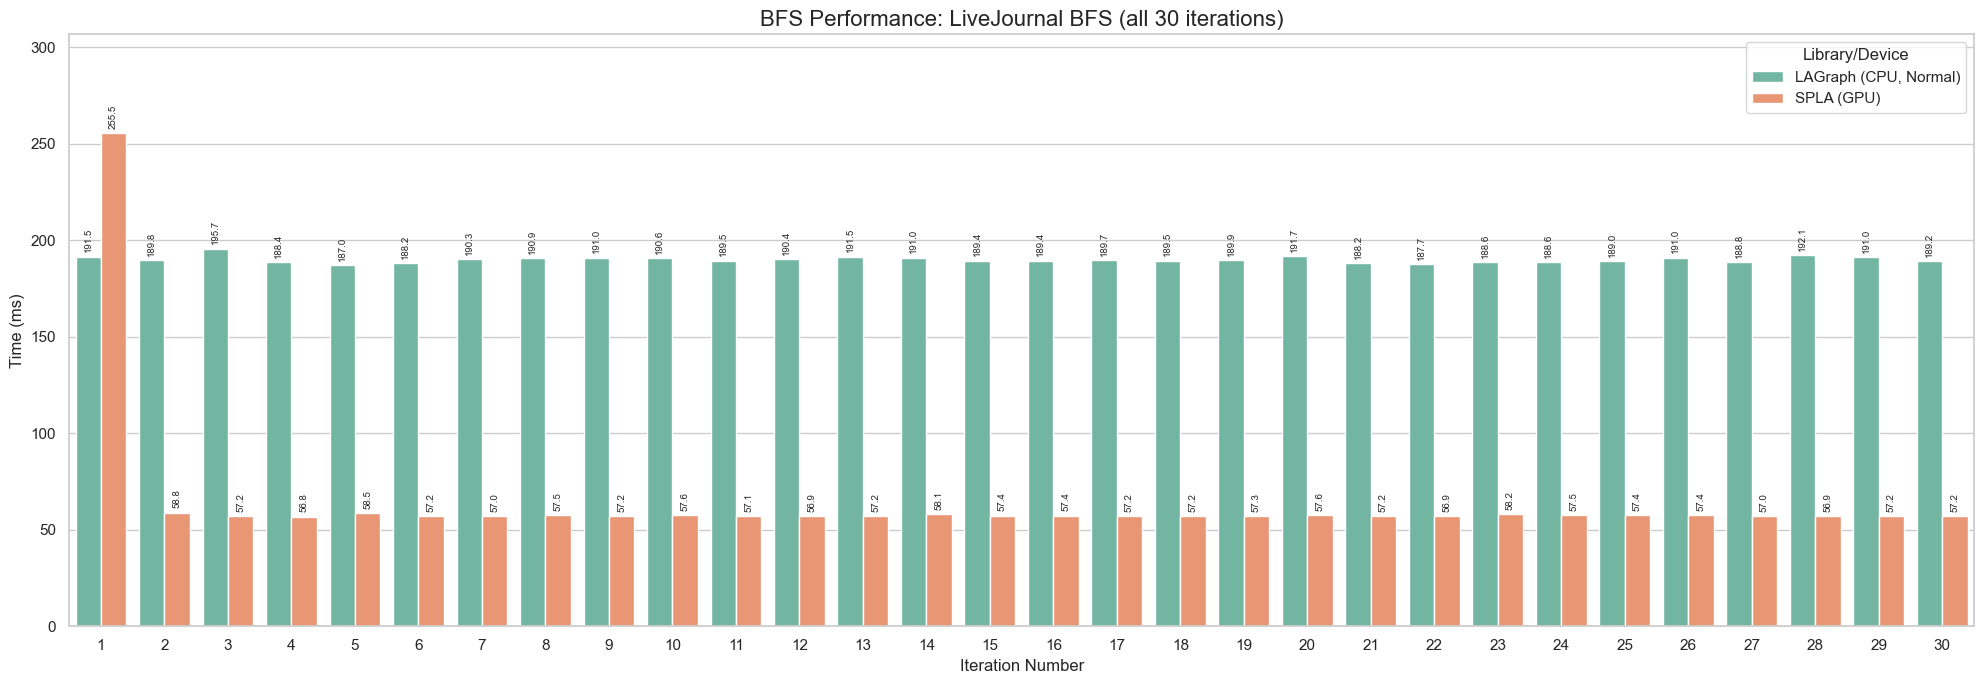

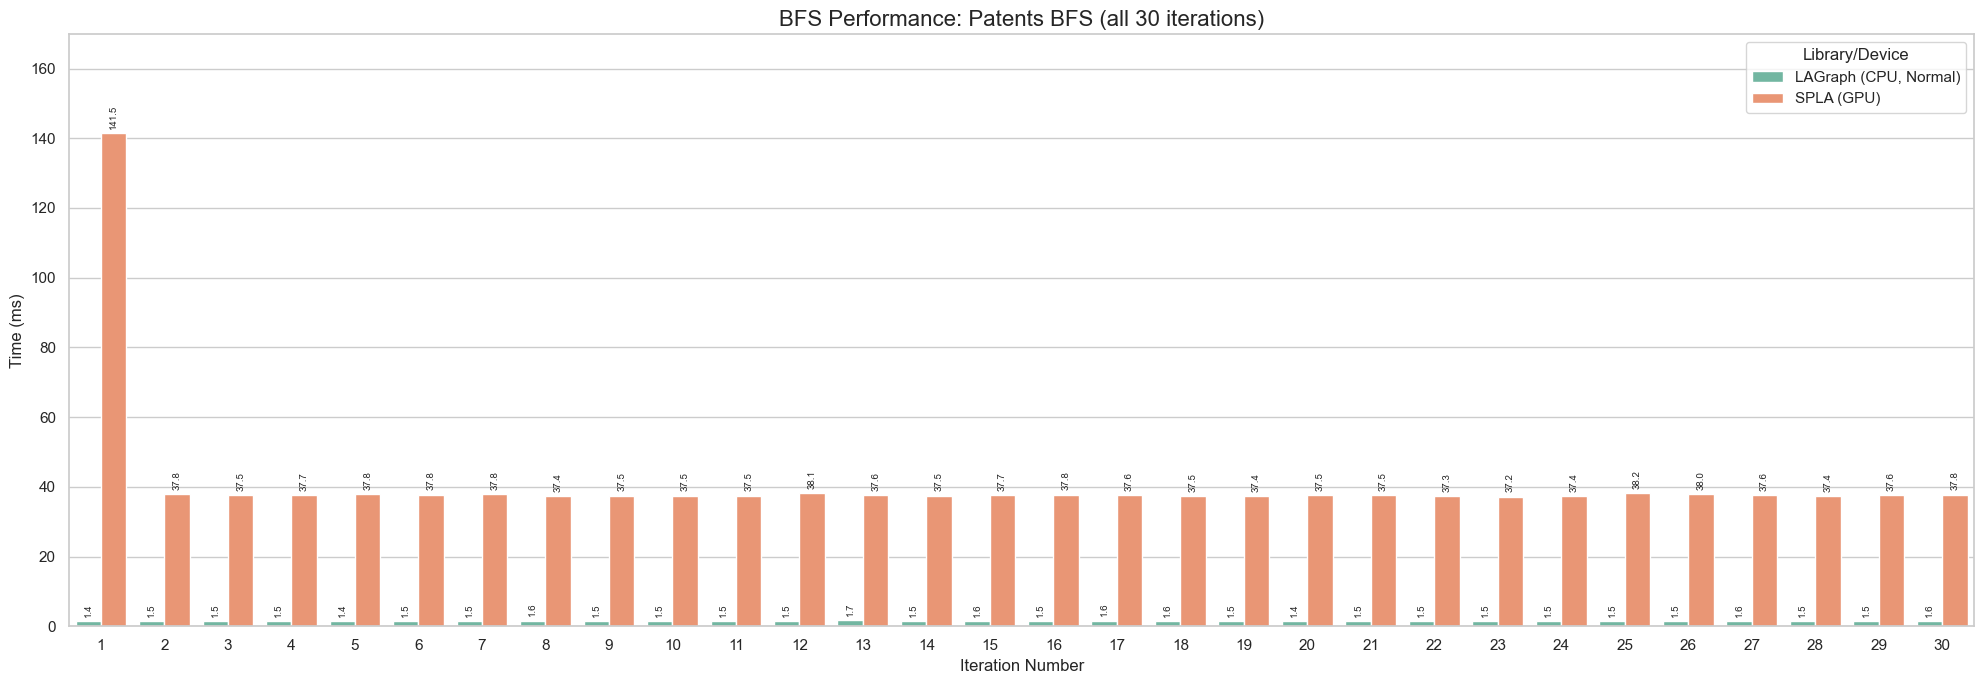

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_bfs = pd.read_csv('bfs/results.csv')

def plot_bfs_iterations(df, graph_filename, title_label):
    data_subset = df[
        (df['Graph'] == graph_filename) & 
        (df['Library'].isin(['LAGraph-Normal', 'SPLA']))
    ].copy()
    
    if data_subset.empty:
        print(f"Нет данных для {graph_filename}")
        return

    data_subset['Iteration'] = data_subset['Iteration'].astype(int)

    label_map = {
        'LAGraph-Normal': 'LAGraph (CPU, Normal)',
        'SPLA': 'SPLA (GPU)'
    }
    data_subset['LibraryLabel'] = data_subset['Library'].map(label_map)
    hue_order = [label_map['LAGraph-Normal'], label_map['SPLA']]

    plt.figure(figsize=(20, 7))
    sns.set_theme(style="whitegrid")
    
    ax = sns.barplot(
        data=data_subset,
        x='Iteration',
        y='Time_ms',
        hue='LibraryLabel',
        hue_order=hue_order,
        palette='Set2',
        width=0.8
    )

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(format(height, '.1f'), 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha = 'center', va = 'bottom', 
                        xytext = (0, 3), 
                        textcoords = 'offset points',
                        fontsize=7, 
                        rotation=90)

    plt.title(f'BFS Performance: {title_label} (all 30 iterations)', fontsize=16)
    plt.ylabel('Time (ms)')
    plt.xlabel('Iteration Number')
    
    plt.legend(title='Library/Device', loc='upper right')

    plt.ylim(0, data_subset['Time_ms'].max() * 1.2)

    plt.tight_layout()
    plt.show()


plot_bfs_iterations(df_bfs, 'soc-LiveJournal1.mtx', 'LiveJournal BFS')

plot_bfs_iterations(df_bfs, 'patents.mtx', 'Patents BFS')

Normality checks (Shapiro-Wilk) for raw runs in graph 2:
  CPU | LAGraph directed: p=0.03947 -> not normal (n=30)
  CPU | LAGraph undirected: p=0.00418 -> not normal (n=30)
  GPU | SPLA undirected: p=0.00000 -> not normal (n=30)


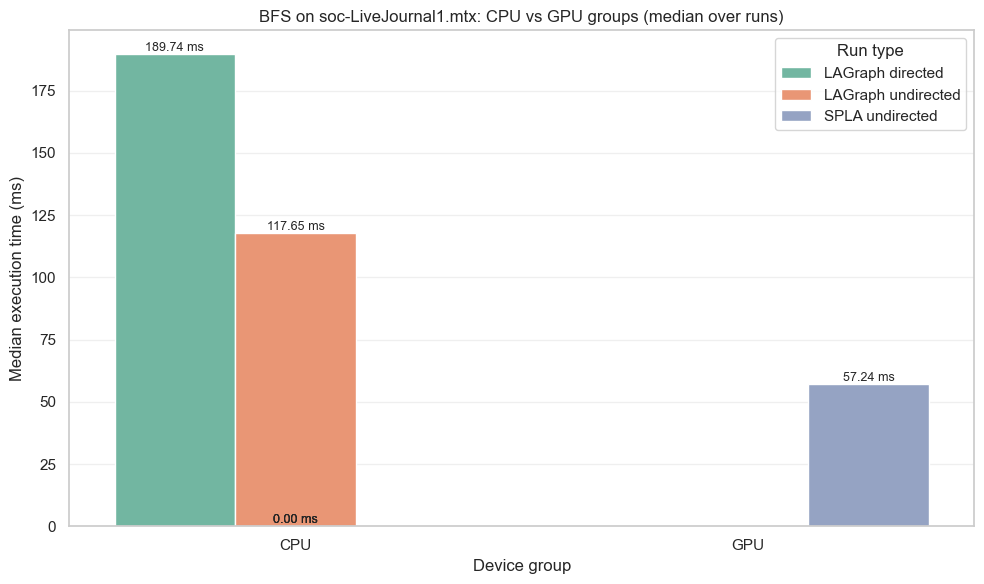

In [126]:
target_graph = 'soc-LiveJournal1.mtx'
plot_df = df[df['Graph'] == target_graph].copy()

plot_df['Variant'] = plot_df['Library'].replace({
    'SPLA': 'SPLA undirected',
    'LAGraph-Normal': 'LAGraph directed',
    'LAGraph-Sym': 'LAGraph undirected'
})

summary_device = (
    plot_df
    .groupby(['Device', 'Variant'], as_index=False)['Time_ms']
    .median()
    .rename(columns={'Time_ms': 'Median_ms'})
)

print('Normality checks (Shapiro-Wilk) for raw runs in graph 2:')
for (device, variant), g in plot_df.groupby(['Device', 'Variant']):
    sample = g['Time_ms'].dropna()
    if len(sample) >= 3:
        stat, p = stats.shapiro(sample)
        verdict = 'normal' if p > 0.05 else 'not normal'
        print(f'  {device} | {variant}: p={p:.5f} -> {verdict} (n={len(sample)})')
    else:
        print(f'  {device} | {variant}: n={len(sample)} (too small for Shapiro)')

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary_device,
    x='Device',
    y='Median_ms',
    hue='Variant',
    order=['CPU', 'GPU'],
    hue_order=['LAGraph directed', 'LAGraph undirected', 'SPLA undirected'],
    palette='Set2'
)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(
            f'{h:.2f} ms',
            (p.get_x() + p.get_width() / 2, h),
            ha='center', va='bottom', fontsize=9
        )

plt.title(f'BFS on {target_graph}: CPU vs GPU groups (median over runs)')
plt.ylabel('Median execution time (ms)')
plt.xlabel('Device group')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Run type')
plt.tight_layout()
plt.savefig("bfs/jl_mean_time.png")
plt.show()

Normality checks (Shapiro-Wilk) for raw runs in graph 3:
  LiveJournal | LAGraph directed (CPU): p=0.03947 -> not normal (n=30)
  LiveJournal | LAGraph undirected (CPU): p=0.00418 -> not normal (n=30)
  LiveJournal | SPLA directed (GPU): p=0.00000 -> not normal (n=30)
  patents | LAGraph directed (CPU): p=0.00618 -> not normal (n=30)
  patents | LAGraph undirected (CPU): p=0.00000 -> not normal (n=30)
  patents | SPLA directed (GPU): p=0.00000 -> not normal (n=30)


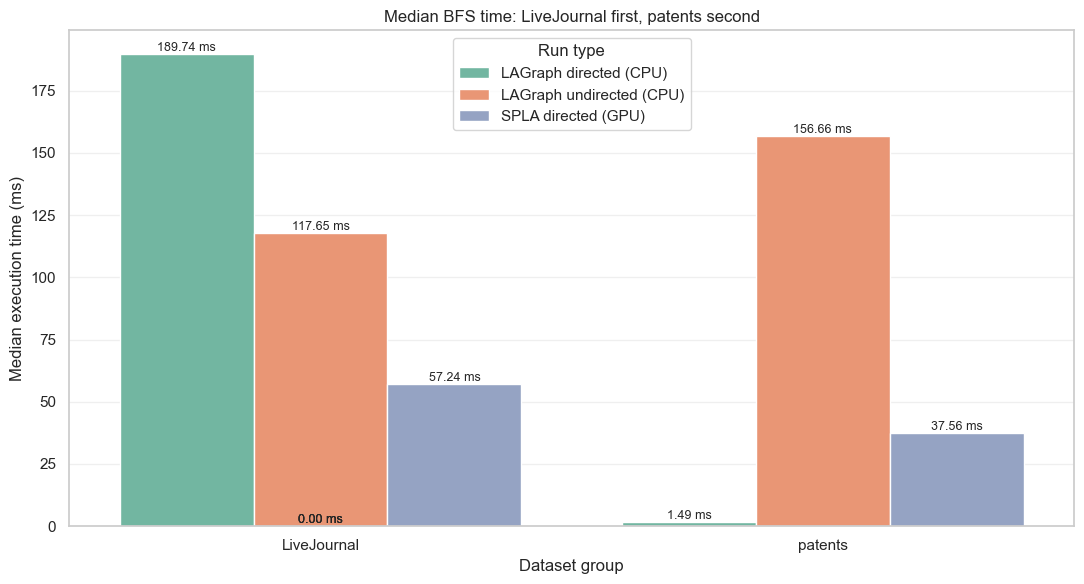

In [125]:
sns.set_theme(style="whitegrid")

base_df = df[df['Graph'].isin(['soc-LiveJournal1.mtx', 'patents.mtx'])].copy()

base_df['GraphGroup'] = base_df['Graph'].map({
    'soc-LiveJournal1.mtx': 'LiveJournal',
    'patents.mtx': 'patents'
})

variant_map = {
    'LAGraph-Sym': 'LAGraph undirected (CPU)',
    'LAGraph-Normal': 'LAGraph directed (CPU)',
    'SPLA': 'SPLA directed (GPU)'
}
base_df['Variant'] = base_df['Library'].map(variant_map)

plot_df = base_df[base_df['Variant'].notna()].copy()

summary = (
    plot_df
    .groupby(['GraphGroup', 'Variant'], as_index=False)['Time_ms']
    .median()
    .rename(columns={'Time_ms': 'Median_ms'})
)

print('Normality checks (Shapiro-Wilk) for raw runs in graph 3:')
for (graph_group, variant), g in plot_df.groupby(['GraphGroup', 'Variant']):
    sample = g['Time_ms'].dropna()
    if len(sample) >= 3:
        stat, p = stats.shapiro(sample)
        verdict = 'normal' if p > 0.05 else 'not normal'
        print(f'  {graph_group} | {variant}: p={p:.5f} -> {verdict} (n={len(sample)})')
    else:
        print(f'  {graph_group} | {variant}: n={len(sample)} (too small for Shapiro)')

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=summary,
    x='GraphGroup',
    y='Median_ms',
    hue='Variant',
    order=['LiveJournal', 'patents'],
    hue_order=['LAGraph directed (CPU)', 'LAGraph undirected (CPU)', 'SPLA directed (GPU)'],
    palette='Set2'
)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(
            f'{h:.2f} ms',
            (p.get_x() + p.get_width() / 2, h),
            ha='center', va='bottom', fontsize=9
        )

plt.title('Median BFS time: LiveJournal first, patents second')
plt.ylabel('Median execution time (ms)')
plt.xlabel('Dataset group')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Run type')
plt.tight_layout()
plt.savefig("bfs/all_mean_time.png")
plt.show()

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_24381/647022821.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='viridis')


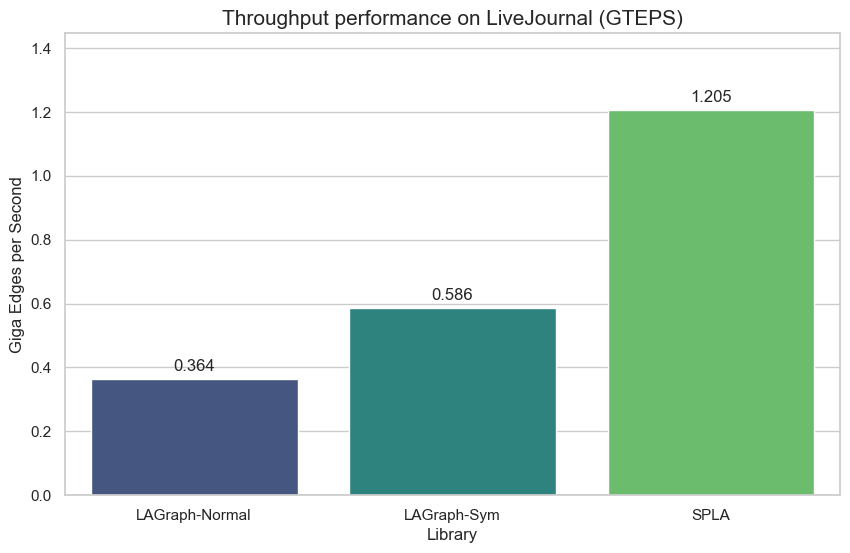

Performance LAGraph-Normal: 0.364 GTEPS
Performance LAGraph-Sym: 0.586 GTEPS
Performance SPLA: 1.205 GTEPS


In [128]:
edges_lj = {
    'soc-LiveJournal1.mtx': 68993773
}

gteps_df = base_df[base_df['Graph'] == 'soc-LiveJournal1.mtx'].copy()

gteps_df = gteps_df.groupby(['Graph', 'Library'])['Time_ms'].median().reset_index()

gteps_df['GTEPS'] = gteps_df.apply(lambda x: edges_lj[x['Graph']] / (x['Time_ms'] * 1e6), axis=1)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Throughput performance on LiveJournal (GTEPS)', fontsize=15)
plt.ylabel('Giga Edges per Second', fontsize=12)
plt.xlabel('Library', fontsize=12)
plt.ylim(0, gteps_df['GTEPS'].max() * 1.2)
plt.savefig("bfs/all_gteps.png")
plt.show()

for index, row in gteps_df.iterrows():
    print(f"Performance {row['Library']}: {row['GTEPS']:.3f} GTEPS")